/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

...

  0%|          | 0/156 [00:00<?, ?it/s]

  0%|          | 0/156 [00:00<?, ?it/s]

  0%|          | 0/156 [00:00<?, ?it/s]

RoBERTa testset size: 624
RoBERTa:
Confusion Matrix:
[[0.89613527 0.10386473]
 [0.47619048 0.52380952]]

Accuracy: 0.7708333333333334
Precision: 0.7876857749469215
Recall: 0.8961352657004831
F1 Score: 0.8384180790960453


(0.7708333333333334,
 0.7876857749469215,
 0.8961352657004831,
 0.8384180790960453)

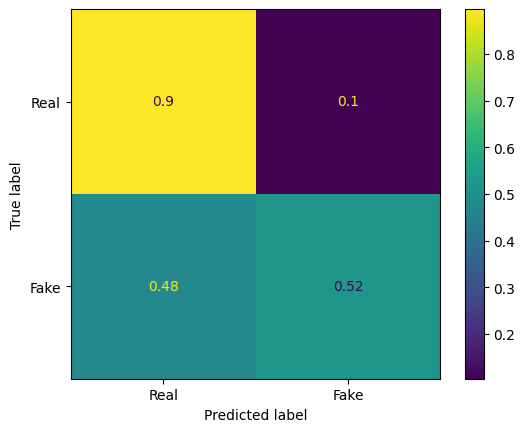

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
from transformers import RobertaForSequenceClassification, RobertaTokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score
from tqdm.notebook import tqdm


class FakeNewsDataset(Dataset):
    def __init__(self, mode, tokenizer, path):
        assert mode in ['train', 'test']
        self.mode = mode
        self.df = pd.read_csv(path + mode + '.tsv', sep='\t').fillna('')
        self.len = len(self.df)
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        statement, label = self.df.iloc[idx, :].values
        label_tensor = torch.tensor(label)

        word_pieces = ['<s>']
        statement = self.tokenizer.tokenize(statement, add_prefix_space=True)
        word_pieces += statement + ['</s>']
        len_st = len(word_pieces)

        ids = self.tokenizer.convert_tokens_to_ids(word_pieces)
        tokens_tensor = torch.tensor(ids)

        segments_tensor = torch.tensor([0] * len_st, dtype=torch.long)

        return (tokens_tensor, segments_tensor, label_tensor)

    def __len__(self):
        return self.len

def create_mini_batch(samples):
    tokens_tensors = [s[0] for s in samples]
    segments_tensors = [s[1] for s in samples]

    if samples[0][2] is not None:
        label_ids = torch.stack([s[2] for s in samples])
    else:
        label_ids = None

    # zero padding
    tokens_tensors = pad_sequence(tokens_tensors, batch_first=True)
    segments_tensors = pad_sequence(segments_tensors, batch_first=True)

    masks_tensors = torch.zeros(tokens_tensors.shape, dtype=torch.long)
    masks_tensors = masks_tensors.masked_fill(tokens_tensors != 0, 1)

    return tokens_tensors, segments_tensors, masks_tensors, label_ids

BATCH_SIZE = 16
MODEL_NAME = 'roberta-base'
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

NUM_LABELS = 2
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS)

# Move model to device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model.to(device)

def evaluate(testloader):
    true = []
    predictions = []
    with torch.no_grad():
        model.eval()
        for data in testloader:
            if next(model.parameters()).is_cuda:
                data = [t.to(device) for t in data if t is not None]

            tokens_tensors, segments_tensors, masks_tensors = data[:3]
            test_outputs = model(input_ids=tokens_tensors,
                               token_type_ids=segments_tensors,
                               attention_mask=masks_tensors)

            logits = test_outputs.logits  # RoBERTa uses 'logits' attribute
            _, pred = torch.max(logits.data, 1)

            labels = data[3]
            true.extend(labels.cpu().tolist())
            predictions.extend(pred.cpu().tolist())

    cm = confusion_matrix(true, predictions, labels=[1, 0], normalize='true')
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot()

    accuracy = accuracy_score(true, predictions)
    precision = precision_score(true, predictions)
    recall = recall_score(true, predictions)
    f1 = f1_score(true, predictions)

    print('\nAccuracy:', accuracy)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)

    return accuracy, precision, recall, f1

trainset = FakeNewsDataset('train', tokenizer=tokenizer, path='./')
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)

# Your training and fine-tuning code remains unchanged
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)
model.to(device)

model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    train_loss = 0.0
    train_acc = 0.0

    loop = tqdm(trainloader)
    for batch_idx, data in enumerate(loop):
        tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]

        optimizer.zero_grad()

        outputs = model(input_ids=tokens_tensors,
                      token_type_ids=segments_tensors,
                      attention_mask=masks_tensors,
                      labels=labels)

        loss = outputs[0]
        loss.backward()
        optimizer.step()

        logits = outputs[1]
        _, pred = torch.max(logits.data, 1)
        train_acc = accuracy_score(pred.cpu().tolist(), labels.cpu().tolist())

        train_loss += loss.item()

        loop.set_description(f'Epoch [{epoch + 1}/{NUM_EPOCHS}]')
        loop.set_postfix(acc=train_acc, loss=train_loss/(batch_idx+1))

# Example usage:
testset_roberta = FakeNewsDataset('test', tokenizer=tokenizer, path='./')
print('RoBERTa testset size:', testset_roberta.__len__())
testloader_roberta = DataLoader(testset_roberta, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)

print('RoBERTa:')
print('Confusion Matrix:')
evaluate(testloader_roberta)